## Tabular training

In [21]:
from fastai.tabular.all import *

In [23]:
path = untar_data(URLs.ADULT_SAMPLE)
print('path',path)

hello
path /Users/Yashwanth.B/.fastai/data/adult_sample


In [37]:
dls = TabularDataLoaders.from_csv(
    path/"adult.csv",
    path=path,
    cat_names=["workclass", "education", "marital-status", "occupation", "relationship", "race", "native-country"],
    cont_names=["education-num", "capital-gain", "fnlwgt", "age"],
    y_names="salary",
    procs=[Categorify, FillMissing, Normalize]
)
dls.show_batch()

/Users/Yashwanth.B/jupyter/jenv/lib/python3.10/site-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to[n].fillna(self.na_dict[n], inplace=True)


,workclass,education,marital-status,occupation,relationship,race,native-country,education-num_na,education-num,capital-gain,fnlwgt,age,salary
0,Private,Bachelors,Never-married,Handlers-cleaners,Own-child,White,United-States,False,13.0,-0.000016,109814.000612,29.000000,<50k
1,Private,Assoc-acdm,Married-civ-spouse,#na#,Husband,White,United-States,True,10.0,-0.000016,174828.999485,48.000000,<50k
2,Private,11th,Never-married,Handlers-cleaners,Own-child,White,United-States,False,7.0,-0.000016,138556.999545,17.999999,<50k
3,State-gov,Bachelors,Never-married,Prof-specialty,Unmarried,Asian-Pac-Islander,United-States,False,13.0,-0.000016,93415.001426,54.000000,>=50k
4,Self-emp-not-inc,Assoc-acdm,Divorced,Sales,Not-in-family,White,United-States,False,12.0,-0.000016,377622.002148,49.000000,<50k
5,Private,HS-grad,Never-married,Sales,Not-in-family,White,United-States,False,9.0,-0.000016,441454.001260,34.000000,<50k
6,Private,Masters,Married-civ-spouse,Prof-specialty,Wife,White,United-States,False,14.0,-0.000016,101824.997461,49.000000,>=50k
7,Local-gov,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,United-States,False,13.0,-0.000016,201409.999827,38.000000,>=50k
8,Self-emp-not-inc,HS-grad,Married-civ-spouse,Exec-managerial,Husband,White,United-States,False,9.0,-0.000016,179556.999900,44.000000,>=50k
9,Private,Bachelors,Never-married,Prof-specialty,Not-in-family,White,United-States,False,13.0,-0.000016,135784.997871,34.000000,<50k


In [41]:
learner = tabular_learner(dls, metrics=[accuracy, error_rate])
learner.fit_one_cycle(1)

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.347728,0.334250,0.851505,0.148495,00:11


In [45]:
import pandas as pd

row = {
    'workclass': 'Private',
    'education': 'Assoc-acdm',
    'marital-status': 'Married-civ-spouse',
    'occupation': 'Sales',
    'relationship': 'Wife',
    'race': 'White',
    'fnlwgt': 101320,
    'education-num': 12,
    'age': 49,
    "capital-gain":-0.000014,
    "native-country":"United-States"
}

row_frame = pd.DataFrame([row])
learner.predict(row_frame.iloc[0])

/Users/Yashwanth.B/jupyter/jenv/lib/python3.10/site-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to[n].fillna(self.na_dict[n], inplace=True)


(   workclass  education  marital-status  occupation  relationship  race  \
 0        5.0        8.0             3.0        13.0           6.0   5.0   
 
    native-country  education-num_na  education-num  capital-gain    fnlwgt  \
 0            40.0               1.0       0.746579     -0.147374 -0.837811   
 
         age  salary  
 0  0.763845     1.0  ,
 tensor(1),
 tensor([0.2484, 0.7516]))

In [46]:
learner.validate()

[0.33425021171569824, 0.851504921913147, 0.14849509298801422]

In [47]:
learner.show_results()

,workclass,education,marital-status,occupation,relationship,race,native-country,education-num_na,education-num,capital-gain,fnlwgt,age,salary,salary_pred
0,2.0,16.0,1.0,2.0,2.0,5.0,40.0,1.0,-0.035440,-0.147374,-0.602133,0.617148,0.0,0.0
1,5.0,12.0,7.0,9.0,5.0,5.0,40.0,1.0,-0.426450,-0.147374,-0.043349,-0.042989,0.0,0.0
2,5.0,12.0,3.0,4.0,1.0,5.0,40.0,1.0,-0.426450,-0.147374,-0.193049,0.397103,1.0,0.0
3,5.0,12.0,3.0,13.0,1.0,5.0,40.0,1.0,-0.426450,-0.147374,-0.431985,0.030360,1.0,0.0
4,5.0,16.0,3.0,4.0,1.0,5.0,40.0,1.0,-0.035440,-0.147374,0.047800,-0.629777,0.0,0.0
5,5.0,10.0,6.0,5.0,2.0,3.0,40.0,1.0,1.137589,-0.147374,1.425888,-0.409731,0.0,0.0
6,5.0,16.0,5.0,2.0,2.0,3.0,1.0,1.0,-0.035440,-0.147374,-0.639733,-1.069868,0.0,0.0
7,5.0,12.0,3.0,8.0,1.0,5.0,40.0,1.0,-0.426450,-0.147374,-0.207871,-0.629777,0.0,0.0
8,7.0,12.0,3.0,5.0,6.0,5.0,40.0,1.0,-0.426450,-0.147374,0.062727,1.423982,1.0,1.0


In [49]:
learner.summary()

<div></div>

TabularModel (Input shape: 64 x 8)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 6              
Embedding                                 60         True      
____________________________________________________________________________
                     64 x 8              
Embedding                                 136        True      
____________________________________________________________________________
                     64 x 5              
Embedding                                 40         True      
____________________________________________________________________________
                     64 x 8              
Embedding                                 128        True      
____________________________________________________________________________
                     64 x 5              
Embedding                                 35         True      
_______________________________________________________________

## Vision fine tuning

In [52]:
from fastai.vision.all import *

path = untar_data(URLs.PETS)
path.ls()

[Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/.DS_Store'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/models'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/annotations')]

In [54]:
files = get_image_files(path/"images")

In [58]:
def label_func(f): return f[0].isupper()
dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(224))

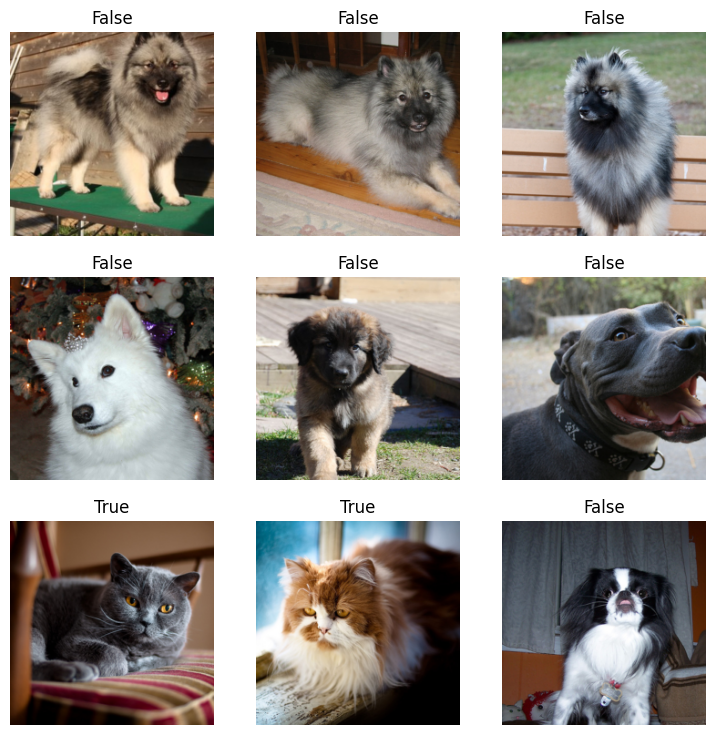

In [59]:
dls.show_batch()

In [60]:
learner = vision_learner(dls, resnet18, metrics=[accuracy, error_rate])

<div></div>

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.211622,0.031697,0.989175,0.010825,00:47


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.068751,0.015580,0.995264,0.004736,00:58


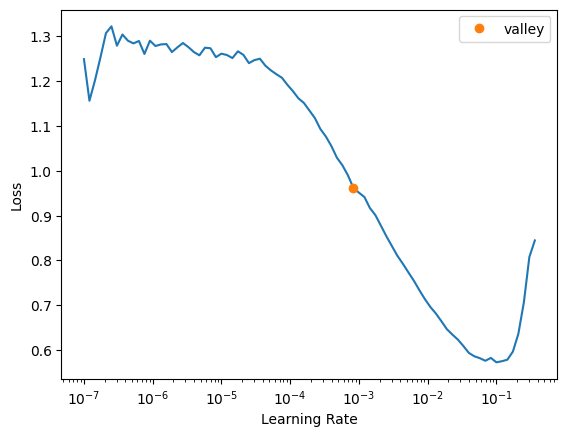

In [66]:
peak = learner.lr_find(suggest_funcs=(valley))
learner.fine_tune(1, peak.valley)

In [68]:
learner.predict(files[1])

('False', tensor(0), tensor([0.9924, 0.0076]))

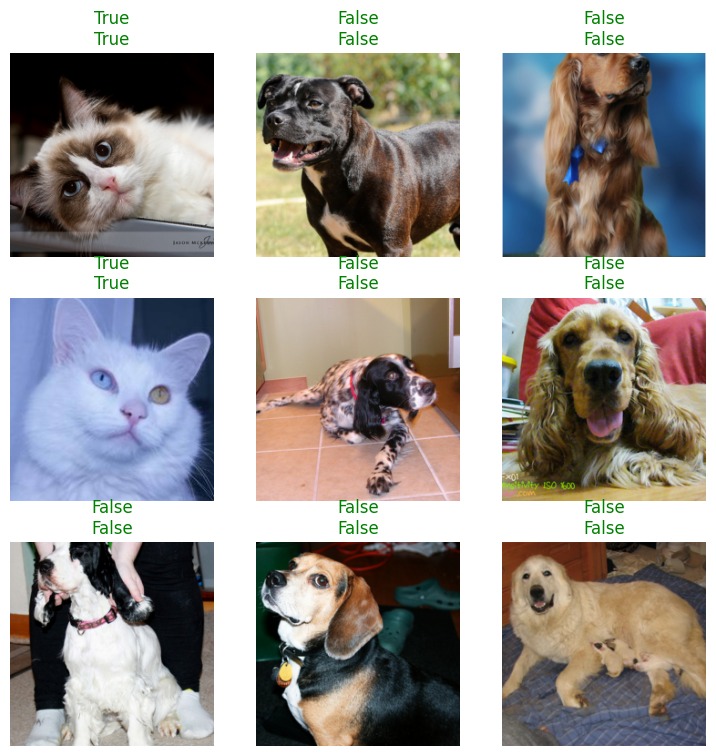

In [69]:
learner.show_results()

In [70]:
learner.summary()

<div></div>

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                      